In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project Roaot:", PROJECT_ROOT)

Project Roaot: /Users/dhairyas87/Documents/Projects/explainable-credit-risk-management/xai-credit-risk-freddie-mac


In [2]:
import importlib

import scripts.build_target_dataset
import scripts.pipeline
import scripts.build_feature_store
import scripts.build_master_dataset
import scripts.combine_quarters
import src.feature_engineering
import scripts.build_modeling_datasets

importlib.reload(scripts.build_target_dataset)
importlib.reload(scripts.build_feature_store)
importlib.reload(scripts.pipeline)
importlib.reload(scripts.build_master_dataset)
importlib.reload(src.feature_engineering)
importlib.reload(scripts.combine_quarters)
importlib.reload(scripts.build_modeling_datasets)

<module 'scripts.build_modeling_datasets' from '/Users/dhairyas87/Documents/Projects/explainable-credit-risk-management/xai-credit-risk-freddie-mac/scripts/build_modeling_datasets.py'>

In [65]:
import scripts.build_target_dataset as btd

dir(btd)

['Path',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'build_target_dataset',
 'create_bssi',
 'create_loan_level_performance',
 'create_stress_flag',
 'create_stress_level',
 'load_origination',
 'load_performance',
 'validate_loan_counts']

In [66]:
from src.schema import ORIGINATION_COLUMNS

In [5]:
ORIGINATION_COLUMNS

['credit_score',
 'first_payment_date',
 'first_time_homebuyer_indicator',
 'maturity_date',
 'msa',
 'mortgage_insurance_pct',
 'num_units',
 'occupancy_status',
 'cltv',
 'dti',
 'original_upb',
 'ltv',
 'interest_rate',
 'channel',
 'prepayment_penalty_indicator',
 'amortization_type',
 'property_state',
 'property_type',
 'postal_code',
 'loan_identifier',
 'loan_purpose',
 'original_loan_term',
 'num_borrowers',
 'seller_name',
 'servicer_name',
 'super_conforming_flag',
 'pre_harp_loan_sequence_number',
 'program_indicator',
 'harp_indicator',
 'property_valuation_method',
 'interest_only_indicator',
 'mortgage_insurance_cancellation_indicator']

In [24]:
from scripts.pipeline import run_pipeline

run_pipeline(
    quarter="all"
)


Processing 2018Q1
Loading data...
Running validation...
Origination Loans : 296816
Performance Loans : 296816
Validation Passed
Creating loan-level dataset...
Saving parquet...
   bssi  stress_flag  stress_level
0     0            0             0
1     1            1             1
2     0            0             0
3     0            0             0
4     0            0             0
stress_level
0    254031
1     32249
2     10536
Name: count, dtype: int64
Done
BUILDING MASTER DATASET

Loading origination data...
Origination shape: (296816, 32)

Loading target dataset...
Target shape: (296816, 8)

Loading performance features...
Performance Features shape: (296816, 18)

Cleaning origination data...

Merging datasets...
After target merge: (296816, 36)
After performance merge: (296816, 50)
Master shape after merge: (296816, 50)

Creating Borrower Serviceability Score...

Validating dataset...
Master dataset validation passed.

Saving dataset...

Dataset saved successfully.
Final shape

NameError: name 'stages_to_run' is not defined

In [13]:
import pandas as pd
master_df = pd.read_parquet(
    "../data/processed/master_dataset_2018Q1.parquet"
)

print(master_df.columns.tolist())

['credit_score', 'first_payment_date', 'first_time_homebuyer_indicator', 'maturity_date', 'msa', 'mortgage_insurance_pct', 'num_units', 'occupancy_status', 'cltv', 'dti', 'original_upb', 'ltv', 'interest_rate', 'channel', 'prepayment_penalty_indicator', 'amortization_type', 'property_state', 'property_type', 'postal_code', 'loan_identifier', 'loan_purpose', 'original_loan_term', 'num_borrowers', 'seller_name', 'servicer_name', 'program_indicator', 'property_valuation_method', 'interest_only_indicator', 'mortgage_insurance_cancellation_indicator', 'ever_ra', 'bssi', 'stress_flag', 'stress_level', 'max_delinquency', 'avg_delinquency', 'months_delinquent', 'loan_age_max', 'loan_age_avg', 'remaining_term_avg', 'current_rate_avg', 'current_rate_max', 'current_rate_min', 'estimated_ltv_avg', 'estimated_ltv_max', 'ever_modified', 'modification_count', 'ever_assistance', 'assistance_count', 'ever_zero_balance', 'rate_volatility', 'credit_score_norm', 'dti_norm', 'interest_rate_norm', 'ltv_norm

In [81]:
import importlib

import scripts.pipeline

importlib.reload(
    scripts.pipeline
)

from scripts.pipeline import run_pipeline

In [82]:
from inspect import signature

print(
    signature(run_pipeline)
)

(stage, quarter=None, version='v1', description='')


In [45]:
run_pipeline(stage="combine")


Found:
master_dataset_2018Q1.parquet
master_dataset_2018Q2.parquet
master_dataset_2018Q3.parquet
master_dataset_2018Q4.parquet
Loading master_dataset_2018Q1.parquet
Loading master_dataset_2018Q2.parquet
Loading master_dataset_2018Q3.parquet
Loading master_dataset_2018Q4.parquet
Combined Shape: (1285434, 65)
Saved: /Users/dhairyas87/Documents/Projects/explainable-credit-risk-management/xai-credit-risk-freddie-mac/data/processed/master_dataset_2018.parquet

Combined dataset created.


In [ ]:
run_pipeline(stage="combine")

In [48]:
from scripts.pipeline import run_pipeline

run_pipeline(
    stage="feature_store",
    version="v1",
    description="Initial dissertation feature store"
)

BUILDING FEATURE STORE
Input Shape: (1285434, 65)
Serviceability score calculated.
Saved: /Users/dhairyas87/Documents/Projects/explainable-credit-risk-management/xai-credit-risk-freddie-mac/data/feature_store/v1/stress_prediction/feature_store.parquet
Shape: (1285434, 48)
Saved: /Users/dhairyas87/Documents/Projects/explainable-credit-risk-management/xai-credit-risk-freddie-mac/data/feature_store/v1/stress_severity/feature_store.parquet
Shape: (1285434, 60)
Saved: /Users/dhairyas87/Documents/Projects/explainable-credit-risk-management/xai-credit-risk-freddie-mac/data/feature_store/v1/serviceability/feature_store.parquet
Shape: (1285434, 60)
Saved: /Users/dhairyas87/Documents/Projects/explainable-credit-risk-management/xai-credit-risk-freddie-mac/data/feature_store/v1/explainability/feature_store.parquet
Shape: (1285434, 65)

Feature Store Version Created: v1


In [50]:
import pandas as pd

df = pd.read_parquet(
    "../data/feature_store/v1/stress_prediction/feature_store.parquet"
)

print(
    df["quarter"]
    .value_counts()
)

quarter
2018Q2    364502
2018Q3    336669
2018Q1    296816
2018Q4    287447
Name: count, dtype: int64


In [56]:
run_pipeline(
    stage="modeling",
    version="v1"
)

BUILDING MODELING DATASETS

Processing stress_prediction

Saved datasets to /Users/dhairyas87/Documents/Projects/explainable-credit-risk-management/xai-credit-risk-freddie-mac/data/feature_store/v1/stress_prediction
Train: (661318, 48)
Valid: (336669, 48)
Test : (287447, 48)

Processing stress_severity

Saved datasets to /Users/dhairyas87/Documents/Projects/explainable-credit-risk-management/xai-credit-risk-freddie-mac/data/feature_store/v1/stress_severity
Train: (661318, 60)
Valid: (336669, 60)
Test : (287447, 60)

Processing serviceability

Saved datasets to /Users/dhairyas87/Documents/Projects/explainable-credit-risk-management/xai-credit-risk-freddie-mac/data/feature_store/v1/serviceability
Train: (661318, 60)
Valid: (336669, 60)
Test : (287447, 60)

Modeling datasets created.


In [57]:
import pandas as pd

train_df = pd.read_parquet(
    "../data/feature_store/v1/stress_prediction/train.parquet"
)

print(
    train_df["stress_flag"]
    .value_counts(normalize=True)
)

stress_flag
0    0.860293
1    0.139707
Name: proportion, dtype: float64


In [62]:
train_df = pd.read_parquet(
    "../data/feature_store/v1/stress_prediction/train.parquet"
)

print(train_df.shape)

print(train_df.dtypes.value_counts())

train_df.columns.tolist()

(661318, 48)
float64    20
int64      14
str        14
Name: count, dtype: int64


['credit_score',
 'first_payment_date',
 'first_time_homebuyer_indicator',
 'maturity_date',
 'msa',
 'mortgage_insurance_pct',
 'num_units',
 'occupancy_status',
 'cltv',
 'dti',
 'original_upb',
 'ltv',
 'interest_rate',
 'channel',
 'prepayment_penalty_indicator',
 'amortization_type',
 'property_state',
 'property_type',
 'postal_code',
 'loan_purpose',
 'original_loan_term',
 'num_borrowers',
 'seller_name',
 'servicer_name',
 'program_indicator',
 'property_valuation_method',
 'interest_only_indicator',
 'mortgage_insurance_cancellation_indicator',
 'stress_flag',
 'loan_age_max',
 'loan_age_avg',
 'remaining_term_avg',
 'current_rate_avg',
 'current_rate_max',
 'current_rate_min',
 'estimated_ltv_avg',
 'estimated_ltv_max',
 'rate_volatility',
 'credit_score_norm',
 'dti_norm',
 'interest_rate_norm',
 'ltv_norm',
 'num_borrowers_norm',
 'eltv_drift',
 'quarter',
 'year',
 'quarter_num',
 'serviceability_score']

In [73]:
from scripts.pipeline import run_pipeline

run_pipeline(
    stage="feature_store",
    version="v2",
    description="""
    Stress prediction dataset cleaned.
    Removed performance leakage and temporal leakage.
    Origination-only stress prediction.
    """
)

BUILDING FEATURE STORE
Input Shape: (1285434, 65)
Serviceability score calculated.
Saved: /Users/dhairyas87/Documents/Projects/explainable-credit-risk-management/xai-credit-risk-freddie-mac/data/feature_store/v2/stress_prediction/feature_store.parquet
Shape: (1285434, 37)
Saved: /Users/dhairyas87/Documents/Projects/explainable-credit-risk-management/xai-credit-risk-freddie-mac/data/feature_store/v2/stress_severity/feature_store.parquet
Shape: (1285434, 60)
Saved: /Users/dhairyas87/Documents/Projects/explainable-credit-risk-management/xai-credit-risk-freddie-mac/data/feature_store/v2/serviceability/feature_store.parquet
Shape: (1285434, 60)
Saved: /Users/dhairyas87/Documents/Projects/explainable-credit-risk-management/xai-credit-risk-freddie-mac/data/feature_store/v2/explainability/feature_store.parquet
Shape: (1285434, 65)

Feature Store Version Created: v2


In [74]:
import pandas as pd

df = pd.read_parquet(
    "../data/feature_store/v2/stress_prediction/feature_store.parquet"
)

print(df.shape)

print(df.columns.tolist())

(1285434, 37)
['credit_score', 'first_payment_date', 'first_time_homebuyer_indicator', 'maturity_date', 'msa', 'mortgage_insurance_pct', 'num_units', 'occupancy_status', 'cltv', 'dti', 'original_upb', 'ltv', 'interest_rate', 'channel', 'prepayment_penalty_indicator', 'amortization_type', 'property_state', 'property_type', 'postal_code', 'loan_purpose', 'original_loan_term', 'num_borrowers', 'seller_name', 'servicer_name', 'program_indicator', 'property_valuation_method', 'interest_only_indicator', 'mortgage_insurance_cancellation_indicator', 'stress_flag', 'credit_score_norm', 'dti_norm', 'interest_rate_norm', 'ltv_norm', 'num_borrowers_norm', 'quarter', 'year', 'quarter_num']


In [75]:
run_pipeline(
    stage="modeling",
    version="v2"
)

BUILDING MODELING DATASETS

Processing stress_prediction

Saved datasets to /Users/dhairyas87/Documents/Projects/explainable-credit-risk-management/xai-credit-risk-freddie-mac/data/feature_store/v2/stress_prediction
Train: (661318, 37)
Valid: (336669, 37)
Test : (287447, 37)

Processing stress_severity

Saved datasets to /Users/dhairyas87/Documents/Projects/explainable-credit-risk-management/xai-credit-risk-freddie-mac/data/feature_store/v2/stress_severity
Train: (661318, 60)
Valid: (336669, 60)
Test : (287447, 60)

Processing serviceability

Saved datasets to /Users/dhairyas87/Documents/Projects/explainable-credit-risk-management/xai-credit-risk-freddie-mac/data/feature_store/v2/serviceability
Train: (661318, 60)
Valid: (336669, 60)
Test : (287447, 60)

Modeling datasets created.


In [4]:
from scripts.pipeline import run_pipeline
run_pipeline(
    stage="diagnostics",
    version="v2"
)


Diagnostics: stress_prediction
stress_flag: removed 0 rows with missing target
Saved diagnostics to /Users/dhairyas87/Documents/Projects/explainable-credit-risk-management/xai-credit-risk-freddie-mac/reports/dissertation_results/v2/diagnostics/stress_prediction

Diagnostics: stress_severity
stress_level: removed 0 rows with missing target
Saved diagnostics to /Users/dhairyas87/Documents/Projects/explainable-credit-risk-management/xai-credit-risk-freddie-mac/reports/dissertation_results/v2/diagnostics/stress_severity

Diagnostics: serviceability
bss_level: removed 8796 rows with missing target
Saved diagnostics to /Users/dhairyas87/Documents/Projects/explainable-credit-risk-management/xai-credit-risk-freddie-mac/reports/dissertation_results/v2/diagnostics/serviceability


<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

In [85]:
df = pd.read_parquet(
    "../data/feature_store/v2/serviceability/train.parquet"
)

print(
    df["bss_level"].isna().sum()
)

print(
    df["bss_level"].value_counts(dropna=False)
)

8796
bss_level
3.0    130507
1.0    130507
2.0    130505
5.0    130505
4.0    130498
NaN      8796
Name: count, dtype: int64


In [3]:
PROJECT_ROOT = Path(
    "/Users/dhairyas87/Documents/Projects/"
    "explainable-credit-risk-management/"
    "xai-credit-risk-freddie-mac"
)

In [6]:
from scripts.train_stress_prediction import (
    train_stress_prediction
)

train_stress_prediction(

    feature_store_root=
    PROJECT_ROOT / "data" / "feature_store",

    model_root=
    PROJECT_ROOT / "models",

    report_root=
    PROJECT_ROOT / "reports" / "dissertation_results",

    version="v2"

)


Training Logistic Regression...
      Metric     Value
0   Accuracy  0.767150
1  Precision  0.280186
2     Recall  0.470688
3         F1  0.351271
4    ROC_AUC  0.721192


In [8]:
!pip install catboost
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.9/28.9 MB 3.9 MB/s  0:00:07 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 4.2 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [catboost]2/3 [catboost]


In [4]:
from scripts.train_stress_prediction import (
    train_stress_prediction
)

train_stress_prediction(

    feature_store_root=
    PROJECT_ROOT / "data" / "feature_store",

    model_root=
    PROJECT_ROOT / "models",

    report_root=
    PROJECT_ROOT
    / "reports"
    / "dissertation_results",

    version="v2"

)


Training Logistic Regression...
      Metric     Value
0   Accuracy  0.767150
1  Precision  0.280186
2     Recall  0.470688
3         F1  0.351271
4    ROC_AUC  0.721192

TRAINING CATBOOST
Rows Train: 661,318
Rows Valid: 336,669
Rows Test : 287,447
Categorical Features: 13
Class Weights: [1.0, np.float64(3.5789092011126624)]
0:	test: 0.7060133	best: 0.7060133 (0)	total: 585ms	remaining: 4m 51s
50:	test: 0.7256403	best: 0.7256403 (50)	total: 32.6s	remaining: 4m 46s
100:	test: 0.7307093	best: 0.7307093 (100)	total: 1m 9s	remaining: 4m 34s
150:	test: 0.7324277	best: 0.7324277 (150)	total: 1m 48s	remaining: 4m 10s
200:	test: 0.7334904	best: 0.7335471 (189)	total: 2m 29s	remaining: 3m 42s
Stopped by overfitting detector  (30 iterations wait)

bestTest = 0.7336824131
bestIteration = 207

Shrink model to first 208 iterations.

CatBoost Results
      Metric     Value
0   Accuracy  0.760857
1  Precision  0.277920
2     Recall  0.491519
3         F1  0.355071
4    ROC_AUC  0.726124


In [7]:
import pandas as pd

df = pd.read_parquet(
    "../data/processed/master_dataset_2018.parquet"
)

targets = [
    "original_upb",
    "interest_rate",
    "original_loan_term"
]

for col in targets:

    print("\n" + "="*60)
    print(col.upper())
    print("="*60)

    print(df[col].describe())

    print("\nMissing %")
    print(
        df[col].isna().mean()
    )


ORIGINAL_UPB
count    1.285434e+06
mean     2.325739e+05
std      1.221986e+05
min      7.000000e+03
25%      1.400000e+05
50%      2.080000e+05
75%      3.050000e+05
max      1.307000e+06
Name: original_upb, dtype: float64

Missing %
0.0

INTEREST_RATE
count    1.285434e+06
mean     4.739801e+00
std      4.687625e-01
min      0.000000e+00
25%      4.500000e+00
50%      4.750000e+00
75%      5.000000e+00
max      7.000000e+00
Name: interest_rate, dtype: float64

Missing %
0.0

ORIGINAL_LOAN_TERM
count    1.285434e+06
mean     3.345158e+02
std      6.112098e+01
min      6.000000e+01
25%      3.600000e+02
50%      3.600000e+02
75%      3.600000e+02
max      5.450000e+02
Name: original_loan_term, dtype: float64

Missing %
0.0


In [8]:
corr_cols = [

    "credit_score",
    "dti",
    "ltv",
    "cltv",

    "original_upb",
    "interest_rate",
    "original_loan_term"
]

print(
    df[corr_cols]
    .corr()
)

                    credit_score       dti       ltv      cltv  original_upb  \
credit_score            1.000000 -0.128288 -0.048980 -0.051654      0.065085   
dti                    -0.128288  1.000000  0.096209  0.098013      0.136680   
ltv                    -0.048980  0.096209  1.000000  0.990823      0.154332   
cltv                   -0.051654  0.098013  0.990823  1.000000      0.165596   
original_upb            0.065085  0.136680  0.154332  0.165596      1.000000   
interest_rate          -0.252956  0.109173  0.136978  0.138400     -0.100112   
original_loan_term     -0.001914  0.124507  0.284881  0.284823      0.162798   

                    interest_rate  original_loan_term  
credit_score            -0.252956           -0.001914  
dti                      0.109173            0.124507  
ltv                      0.136978            0.284881  
cltv                     0.138400            0.284823  
original_upb            -0.100112            0.162798  
interest_rate          

In [9]:
for col in [

    "original_upb",

    "interest_rate",

    "original_loan_term"

]:

    print("\n")
    print(col)

    print(
        df[col]
        .value_counts()
        .head(20)
    )



original_upb
original_upb
453000    22173
200000    17099
100000    13937
150000    13102
160000    10181
300000     9976
180000     9520
120000     8582
140000     8493
250000     7967
170000     7452
240000     7343
175000     7151
125000     6996
130000     6879
280000     6778
190000     6713
176000     6567
165000     6486
220000     6471
Name: count, dtype: int64


interest_rate
interest_rate
4.750    166739
4.875    166108
4.625    131324
4.500    129001
4.375     87551
5.125     71704
5.250     65788
5.000     65311
4.250     59624
5.375     43851
4.125     41694
4.990     35235
5.500     30185
3.875     30021
4.000     27518
5.625     19311
5.750     17464
3.750     13359
5.875     11618
3.990      9564
Name: count, dtype: int64


original_loan_term
original_loan_term
360    1086837
180     142746
240      42708
120       5323
300       4201
144        350
348        278
168        233
156        226
132        216
276        198
324        176
359        174
216        136


In [10]:
import numpy as np

df["log_upb"] = np.log1p(
    df["original_upb"]
)

print(
    df["log_upb"].describe()
)

count    1.285434e+06
mean     1.221260e+01
std      5.586784e-01
min      8.853808e+00
25%      1.184940e+01
50%      1.224530e+01
75%      1.262807e+01
max      1.408325e+01
Name: log_upb, dtype: float64


<Axes: >

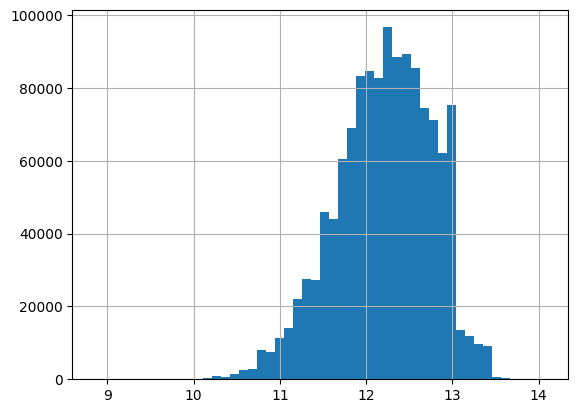

In [11]:
df["log_upb"].hist(
    bins=50
)

In [2]:
from scripts.build_lending_recommendation_feature_store import (
    build_lending_recommendation_feature_store
)

build_lending_recommendation_feature_store(

    master_dataset_path=
    PROJECT_ROOT
    / "data"
    / "processed"
    / "master_dataset_2018.parquet",

    output_root=
    PROJECT_ROOT
    / "data"
    / "feature_store",

    version="v3"

)

BUILDING LENDING RECOMMENDATION FEATURE STORE
Input Shape: (1285434, 65)

Creating Loan Amount Dataset...
Loan Amount Shape: (1285434, 21)

Creating Interest Rate Dataset...
Interest Rate Shape: (1285434, 21)

Creating Loan Term Dataset...
Loan Term Shape: (1285434, 21)

LENDING FEATURE STORE COMPLETE


{'loan_amount':          credit_score first_time_homebuyer_indicator   dti  num_borrowers  \
 0               785.0                              N  34.0              1   
 1               761.0                              N  43.0              1   
 2               726.0                              N  15.0              2   
 3               678.0                              Y  39.0              2   
 4               798.0                              N  17.0              2   
 ...               ...                            ...   ...            ...   
 1285429         697.0                              N  36.0              1   
 1285430         782.0                              N  39.0              1   
 1285431         769.0                              N  42.0              2   
 1285432         806.0                              N  21.0              2   
 1285433         671.0                              N  32.0              1   
 
         occupancy_status property_type propert

In [3]:
import pandas as pd
pd.read_parquet(
    "../data/feature_store/v3/loan_amount/feature_store.parquet"
).shape



(1285434, 21)

In [6]:
pd.read_parquet(
    "../data/feature_store/v3/interest_rate/feature_store.parquet"
).shape



(1285434, 36)

In [7]:
pd.read_parquet(
    "../data/feature_store/v3/loan_term/feature_store.parquet"
).shape

(1285434, 36)

In [5]:
df = pd.read_parquet(
    "../data/feature_store/v3/loan_amount/feature_store.parquet"
)

print(df.columns.tolist())

['credit_score', 'first_time_homebuyer_indicator', 'dti', 'num_borrowers', 'occupancy_status', 'property_type', 'property_state', 'msa', 'num_units', 'ltv', 'cltv', 'mortgage_insurance_pct', 'channel', 'loan_purpose', 'program_indicator', 'property_valuation_method', 'interest_only_indicator', 'mortgage_insurance_cancellation_indicator', 'quarter', 'quarter_num', 'target']


In [6]:
from scripts.build_lending_modeling_datasets import (
    build_lending_modeling_datasets
)

train_df = build_lending_modeling_datasets(

    feature_store_root=
    PROJECT_ROOT
    / "data"
    / "feature_store",

    version="v3"

)

BUILDING LENDING MODELING DATASETS

Processing loan_amount

Saved datasets to /Users/dhairyas87/Documents/Projects/explainable-credit-risk-management/xai-credit-risk-freddie-mac/data/feature_store/v3/loan_amount
Train: (1028347, 21)
Valid: (128543, 21)
Test : (128544, 21)

Processing interest_rate

Saved datasets to /Users/dhairyas87/Documents/Projects/explainable-credit-risk-management/xai-credit-risk-freddie-mac/data/feature_store/v3/interest_rate
Train: (1028347, 21)
Valid: (128543, 21)
Test : (128544, 21)

Processing loan_term

Saved datasets to /Users/dhairyas87/Documents/Projects/explainable-credit-risk-management/xai-credit-risk-freddie-mac/data/feature_store/v3/loan_term
Train: (1028347, 21)
Valid: (128543, 21)
Test : (128544, 21)

Modeling datasets created.


In [8]:
import pandas as pd

train_df = pd.read_parquet(
    PROJECT_ROOT
    / "data"
    / "feature_store"
    / "v3"
    / "loan_amount"
    / "train.parquet"
)

valid_df = pd.read_parquet(
    PROJECT_ROOT
    / "data"
    / "feature_store"
    / "v3"
    / "loan_amount"
    / "valid.parquet"
)

test_df = pd.read_parquet(
    PROJECT_ROOT
    / "data"
    / "feature_store"
    / "v3"
    / "loan_amount"
    / "test.parquet"
)

In [10]:
train_df["quarter"].value_counts(normalize=True)



quarter
2018Q2    0.283403
2018Q3    0.261843
2018Q1    0.231182
2018Q4    0.223572
Name: proportion, dtype: float64

In [11]:
valid_df["quarter"].value_counts(normalize=True)



quarter
2018Q2    0.284022
2018Q3    0.261757
2018Q1    0.230864
2018Q4    0.223357
Name: proportion, dtype: float64

In [12]:
test_df["quarter"].value_counts(normalize=True)

quarter
2018Q2    0.284385
2018Q3    0.262610
2018Q1    0.228754
2018Q4    0.224250
Name: proportion, dtype: float64

In [13]:
print(
    train_df.isna()
    .sum()
    .sort_values(
        ascending=False
    )
    .head(20)
)

msa                                          103901
dti                                           10575
credit_score                                    332
cltv                                             28
ltv                                              15
occupancy_status                                  0
loan_purpose                                      0
quarter_num                                       0
quarter                                           0
mortgage_insurance_cancellation_indicator         0
interest_only_indicator                           0
property_valuation_method                         0
program_indicator                                 0
channel                                           0
property_type                                     0
mortgage_insurance_pct                            0
first_time_homebuyer_indicator                    0
num_units                                         0
num_borrowers                                     0
property_sta

In [14]:
print(train_df.shape)

(1028347, 21)


In [2]:
from scripts.train_loan_amount import (
    train_loan_amount
)

train_loan_amount(
    feature_store_root=
    PROJECT_ROOT / "data" / "feature_store",

    model_root=
    PROJECT_ROOT / "models",

    report_root=
    PROJECT_ROOT / "reports" / "dissertation_results",

    version="v3"
)

TRAINING LOAN AMOUNT MODEL
Train: (1028347, 21)
Valid: (128543, 21)
Test : (128544, 21)

Checking Data Types...
first_time_homebuyer_indicator str
occupancy_status str
property_type str
property_state str
msa str
channel str
loan_purpose str
program_indicator str
property_valuation_method str
interest_only_indicator str
mortgage_insurance_cancellation_indicator str
quarter str

Training Linear Regression...

Results
  Metric     Value
0   RMSE  0.392616
1    MAE  0.305968
2   MAPE  2.526218
3     R2  0.503114

TRAINING CATBOOST
0:	learn: 0.5525271	test: 0.5494590	best: 0.5494590 (0)	total: 625ms	remaining: 10m 24s
100:	learn: 0.3949167	test: 0.3925624	best: 0.3925624 (100)	total: 51s	remaining: 7m 34s
200:	learn: 0.3832304	test: 0.3810464	best: 0.3810464 (200)	total: 1m 48s	remaining: 7m 10s
300:	learn: 0.3790119	test: 0.3770674	best: 0.3770674 (300)	total: 2m 54s	remaining: 6m 45s
400:	learn: 0.3767421	test: 0.3749451	best: 0.3749451 (400)	total: 4m 1s	remaining: 6m
500:	learn: 0.3752

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['credit_score','first_time_homebuyer_indicator','dti',..., 'mortgage_insurance_cancellation_indicator','quarter','quarter_num']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` wil